### M evaluation

Does the metric surrogate M accurately predict PSNR and CLIP?

M is trained to map (image, mask, prompts, t_start, t_end) → (psnr, clip) without rendering. This notebook loads the latest `train_m.py` checkpoint and evaluates fit on the saved train / val / test splits.

| What we test | |
|---|---|
| Pointwise error | MAE, RMSE, R² per metric head on every grid cell |
| Ranking utility | Can M distinguish good vs bad cells within an image? |
| Calibration | Are predicted values systematically compressed toward the mean? |
| Surface shape | Do predicted 11×11 heatmaps match true grid topology? |

| How to read outcomes | |
|---|---|
| Train ≪ val/test error | Overfitting; more data or regularization needed |
| Val ~ test error | Split is stable; trust test numbers |
| High R² + low MAE | Good absolute fit; still check calibration plots |
| MAE ≫ within-image range | M cannot resolve timestep differences (useless for T) |
| Calibration curve below diagonal | Predictions regressed toward mean; ranking may fail |
| Flat predicted heatmaps | M ignores timesteps; T will collapse to one cell |

| Setting | Purpose |
|---|---|
| `PLOT_SPLIT` | Which split drives diagnostic plots (default: `test`) |
| `GPU` | Inference device (`None` = default cuda, int = `cuda:N`, `"cpu"`) |

In [ ]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "settings.py").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "models" / "modified-classification"
ROOT = NOTEBOOK_DIR.parents[1]
for p in (ROOT, NOTEBOOK_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import settings
from run_config import resolve_run_dir, apply_run_config, settings_value_diff
from settings import OUTPUTS_DIR

# Optional override: RUN_DIR = NOTEBOOK_DIR / "outputs" / "..." / "20260709_144025"
RUN_DIR = resolve_run_dir(OUTPUTS_DIR)
apply_run_config(RUN_DIR)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from model_m import MetricPredictor
from model_t import TimestepPredictor
from data_io import load_metrics, precompute_embeddings, df_to_metric_grids
from _helpers import CombinedScoreBounds, resolve_device
from settings import *


/data/home/mirick/miniconda3/envs/chordedit/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
diffs = settings_value_diff(settings, RUN_DIR)
if diffs:
    print(f"Settings differences (live vs {RUN_DIR.name}/config.json):")
    for line in diffs:
        print(line)
else:
    print(f"Run config matches live settings ({RUN_DIR.name}/config.json).")

In [2]:
# Inference device: None = default cuda, int = cuda:N, "cpu" = cpu.
GPU = None
DEVICE = resolve_device(GPU)
print(f"device: {DEVICE}")

# Split used by diagnostic plots below.
PLOT_SPLIT = "test"

def fig_title(subtitle: str, split: str | None = None) -> str:
    title = f"{subtitle} for $\\hat{{M}}$ on {METRICS_CSV.stem}, $\\delta={{{TARGET_T_DELTA:.2f}}}$"
    if split is not None:
        title += f" ({split})"
    return title

device: cuda


In [ ]:
# Saved train/val/test splits from train_m (RUN_DIR set in imports cell).
splits = {
    name: pd.read_parquet(RUN_DIR / f"{name}.parquet.gz")
    for name in ("train", "val", "test")
}
print(
    f"Run: {RUN_DIR.name}  "
    + "  ".join(
        f"{name}={len(df)} cells ({df['sample_id'].nunique()} samples)"
        for name, df in splits.items()
    )
)

full_df = load_metrics()
T_START_VALUES = np.sort(full_df.t_start.unique())
T_END_VALUES = np.sort(full_df.t_end.unique())
N1, N2 = len(T_START_VALUES), len(T_END_VALUES)
CELLS = N1 * N2

Run: 20260709_144025  train=9680 cells (80 samples)  val=1210 cells (10 samples)  test=1210 cells (10 samples)


In [4]:
weights_path = RUN_DIR / "regressor_weights.pt"
ckpt = torch.load(weights_path, map_location=DEVICE, weights_only=False)
model = MetricPredictor(freeze_encoders=FREEZE_ENCODERS, device=DEVICE)
model.regressor.load_state_dict(ckpt["regressor_state_dict"])
model.regressor.set_target_stats(ckpt["target_mean"], ckpt["target_std"])
model.regressor.to(DEVICE).eval()

combined_bounds = None
if "combined_score_bounds" in ckpt:
    pmn, pmx, cmn, cmx = ckpt["combined_score_bounds"]
    combined_bounds = CombinedScoreBounds(float(pmn), float(pmx), float(cmn), float(cmx))
t_predictor = TimestepPredictor(
    model,
    t_start_values=T_START_VALUES,
    t_end_values=T_END_VALUES,
    scalar_stats=combined_bounds,
)

Loading weights: 100%|██████████| 372/372 [00:00<00:00, 8984.53it/s]


In [5]:
def eval_split(df: pd.DataFrame) -> dict:
    sample_ids = sorted(df.sample_id.unique())
    emb = precompute_embeddings(df.drop_duplicates("sample_id"), model, DEVICE)
    true_psnr, _ = df_to_metric_grids(df, sample_ids, T_START_VALUES, T_END_VALUES, PSNR_COL)
    true_clip, _ = df_to_metric_grids(df, sample_ids, T_START_VALUES, T_END_VALUES, CLIP_COL)
    pred_psnr = np.zeros_like(true_psnr)
    pred_clip = np.zeros_like(true_clip)
    for k, sid in enumerate(sample_ids):
        e = emb[sid]
        grid = t_predictor.predict_grid_from_emb(e["img"], e["mask"], e["src"], e["tar"])
        pred_psnr[k], pred_clip[k] = grid.psnr_grid, grid.clip_grid
    return {
        "sample_ids": sample_ids,
        "n_img": len(sample_ids),
        "true_psnr": true_psnr,
        "true_clip": true_clip,
        "pred_psnr": pred_psnr,
        "pred_clip": pred_clip,
    }


split_results = {name: eval_split(df) for name, df in splits.items()}

true_psnr = split_results[PLOT_SPLIT]["true_psnr"]
true_clip = split_results[PLOT_SPLIT]["true_clip"]
pred_psnr = split_results[PLOT_SPLIT]["pred_psnr"]
pred_clip = split_results[PLOT_SPLIT]["pred_clip"]
SAMPLE_IDS = split_results[PLOT_SPLIT]["sample_ids"]
N_IMG = split_results[PLOT_SPLIT]["n_img"]
print(f"{PLOT_SPLIT} grids: {true_psnr.shape}  ({N_IMG} images x {N1}x{N2} cells)")

test grids: (10, 11, 11)  (10 images x 11x11 cells)


In [6]:

"""
Global pointwise error — one table per split (train / val / test).

For every labeled grid cell, compare M's predicted PSNR and CLIP to ground truth.

Metrics:
  - MAE:  average absolute error in raw units (PSNR dB, CLIP score).
  - RMSE: penalizes large outliers more than MAE.
  - R²:   fraction of variance explained; 1.0 = perfect, 0 = predicting the mean.

Interpretation:
  - PSNR MAE ~1-3 dB with R² > 0.7  -> strong surrogate for structure fidelity.
  - CLIP MAE depends on score scale; compare across splits, not to PSNR directly.
  - R² near 0 or negative         -> model no better than the mean; not usable.
  - Train R² much higher than test -> overfitting; do not deploy this checkpoint.
  - Similar val and test tables    -> generalization estimate is reliable.
"""

def _metrics(true_g, pred_g, name):
    e = (pred_g - true_g).ravel()
    t = true_g.ravel()
    ss_res = (e ** 2).sum()
    ss_tot = ((t - t.mean()) ** 2).sum()
    return {
        "metric": name,
        "mae": float(np.abs(e).mean()),
        "rmse": float(np.sqrt((e ** 2).mean())),
        "r2": float(1 - ss_res / ss_tot) if ss_tot > 0 else float("nan"),
    }

split_summaries = {}
for split_name in ("train", "val", "test"):
    r = split_results[split_name]
    rows = [
        _metrics(r["true_psnr"], r["pred_psnr"], PSNR_COL),
        _metrics(r["true_clip"], r["pred_clip"], CLIP_COL),
    ]
    summary = pd.DataFrame(rows)
    split_summaries[split_name] = summary
    print(f"\n{fig_title('Global MAE / RMSE / R²', split_name)}  ({r['n_img']} samples, {r['true_psnr'].size} cells)")
    print(summary.to_string(index=False))



Global MAE / RMSE / R² for $\hat{M}$ on id_to_metrics_ultraeditregion100, $\delta={0.00}$ (train)  (80 samples, 9680 cells)
                                metric      mae     rmse       r2
                                  psnr 0.772067 1.022752 0.958501
clip_similarity_target_image_edit_part 1.548205 2.033941 0.829117

Global MAE / RMSE / R² for $\hat{M}$ on id_to_metrics_ultraeditregion100, $\delta={0.00}$ (val)  (10 samples, 1210 cells)
                                metric      mae     rmse        r2
                                  psnr 2.007497 2.700153  0.774500
clip_similarity_target_image_edit_part 3.407380 4.305000 -0.310242

Global MAE / RMSE / R² for $\hat{M}$ on id_to_metrics_ultraeditregion100, $\delta={0.00}$ (test)  (10 samples, 1210 cells)
                                metric      mae     rmse        r2
                                  psnr 1.392976 1.781258  0.884721
clip_similarity_target_image_edit_part 3.782772 5.110028 -0.004752


within-image CLIP range (test): median=11.6017  p10=9.4901  MAE=3.783
within-image PSNR range (test): median=20.128  p10=16.792  MAE=1.393


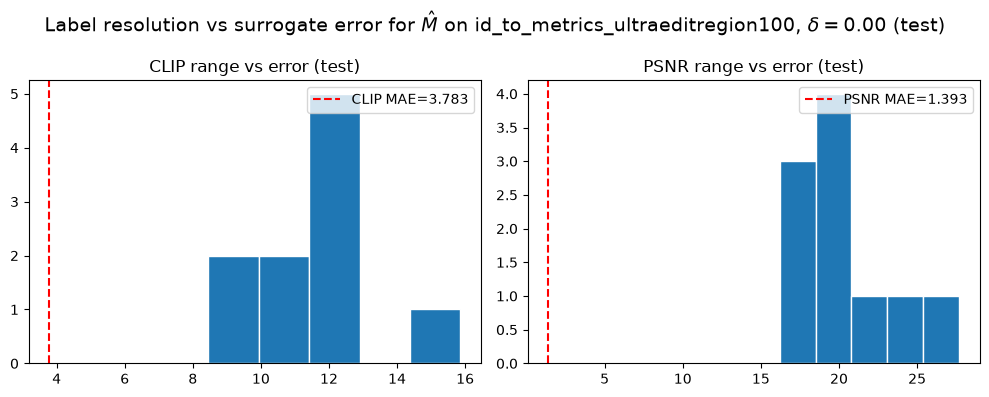

In [7]:

"""
Label resolution vs surrogate error — can M resolve within-image grid variation?

For each image, compute the true PSNR/CLIP range across the 11x11 grid (how much
quality actually varies with timestep choice). Compare to global MAE.

Interpretation:
  - Median range >> MAE (red dashed line left of histogram bulk)
      -> M error is small relative to real variation; timestep ranking is feasible.
  - MAE >= median range
      -> M noise drowns out real differences; T selection will be near-random.
  - Very low p10 range (many images with flat true grids)
      -> those images don't benefit from timestep search regardless of M quality.
  - CLIP range and PSNR range can differ; both heads must pass for reliable T.
"""

clip_range = true_clip.max(axis=(1, 2)) - true_clip.min(axis=(1, 2))
psnr_range = true_psnr.max(axis=(1, 2)) - true_psnr.min(axis=(1, 2))
clip_mae = np.abs(pred_clip - true_clip).mean()
psnr_mae = np.abs(pred_psnr - true_psnr).mean()

print(f"within-image CLIP range ({PLOT_SPLIT}): median={np.median(clip_range):.4f}  p10={np.percentile(clip_range, 10):.4f}  MAE={clip_mae:.3f}")
print(f"within-image PSNR range ({PLOT_SPLIT}): median={np.median(psnr_range):.3f}  p10={np.percentile(psnr_range, 10):.3f}  MAE={psnr_mae:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(clip_range, bins=min(30, max(5, N_IMG // 2)), edgecolor="white")
axes[0].axvline(clip_mae, color="r", linestyle="--", label=f"CLIP MAE={clip_mae:.3f}")
axes[0].legend(); axes[0].set_title(f"CLIP range vs error ({PLOT_SPLIT})")
axes[1].hist(psnr_range, bins=min(30, max(5, N_IMG // 2)), edgecolor="white")
axes[1].axvline(psnr_mae, color="r", linestyle="--", label=f"PSNR MAE={psnr_mae:.3f}")
axes[1].legend(); axes[1].set_title(f"PSNR range vs error ({PLOT_SPLIT})")
fig.suptitle(fig_title("Label resolution vs surrogate error", PLOT_SPLIT), fontsize=14)
plt.tight_layout(); plt.show()


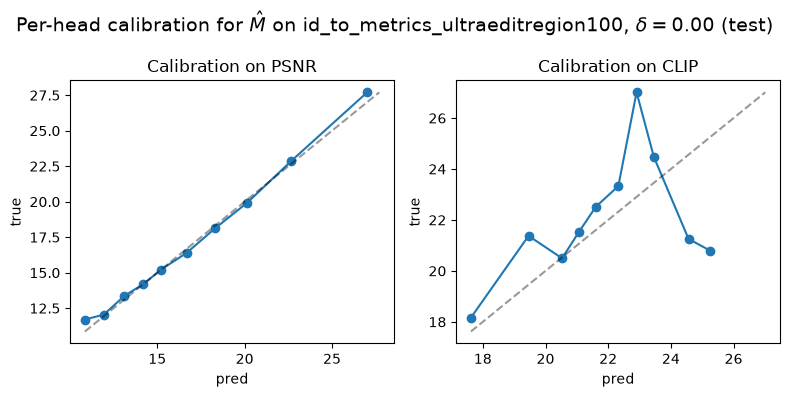

In [8]:

"""
Per-head calibration — are predictions systematically shrunk toward the mean?

Bin predicted values into deciles; plot mean predicted (x) vs mean true (y) per bin.
The dashed line is perfect calibration (pred == true).

Interpretation:
  - Points on the diagonal        -> well-calibrated absolute predictions.
  - Curve below diagonal (compress) -> M underestimates extremes; argmax may pick
      mediocre cells because all predictions cluster near the mean.
  - Curve above diagonal          -> overconfident extremes; less common here.
  - Flat horizontal segment       -> M outputs nearly constant values in that range.
  - Good calibration on test but bad on train is unusual; watch for split mismatch.
"""

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, true_g, pred_g, name in [(axes[0], true_psnr, pred_psnr, "PSNR"), (axes[1], true_clip, pred_clip, "CLIP")]:
    p, t = pred_g.ravel(), true_g.ravel()
    bins = np.quantile(p, np.linspace(0, 1, 11)); bins[0] -= 1e-6; bins[-1] += 1e-6
    idx = np.digitize(p, bins)
    bx, by = [], []
    for b in range(1, 11):
        mask = idx == b
        if mask.any():
            bx.append(p[mask].mean()); by.append(t[mask].mean())
    ax.plot(bx, by, "o-")
    lo, hi = min(bx + by), max(bx + by)
    ax.plot([lo, hi], [lo, hi], "k--", alpha=0.4)
    ax.set_title(f"Calibration on {name}"); ax.set_xlabel("pred"); ax.set_ylabel("true")
fig.suptitle(fig_title("Per-head calibration", PLOT_SPLIT), fontsize=14)
plt.tight_layout(); plt.show()


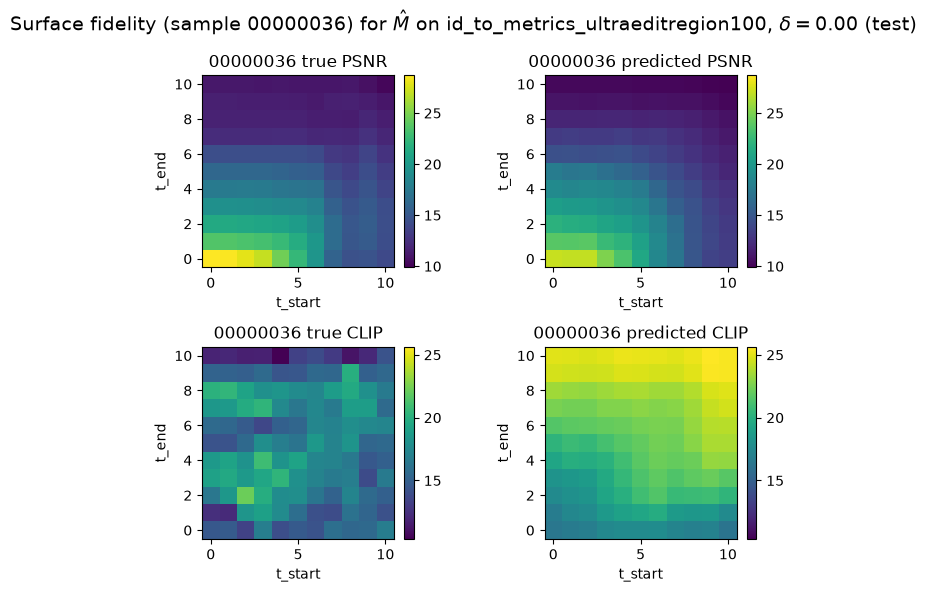

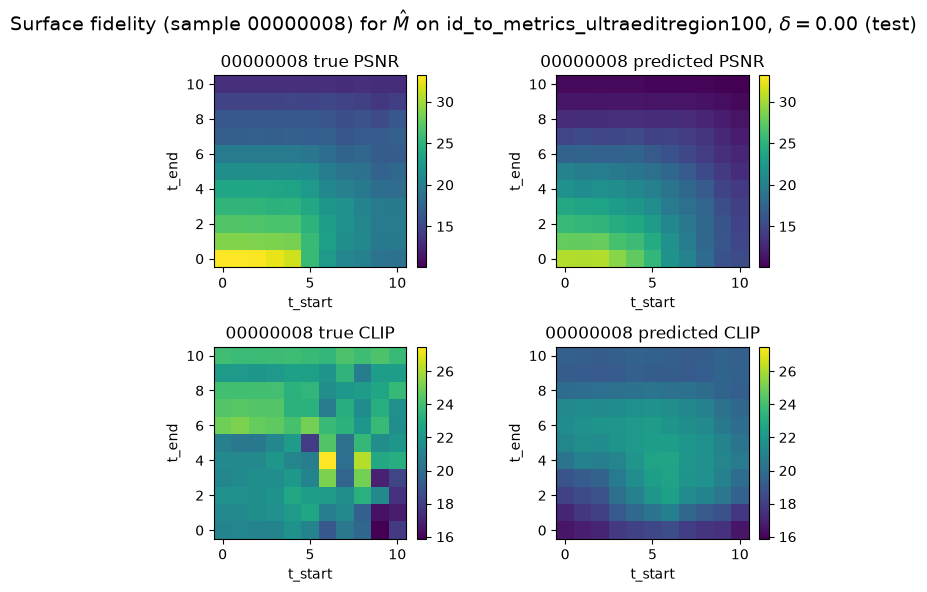

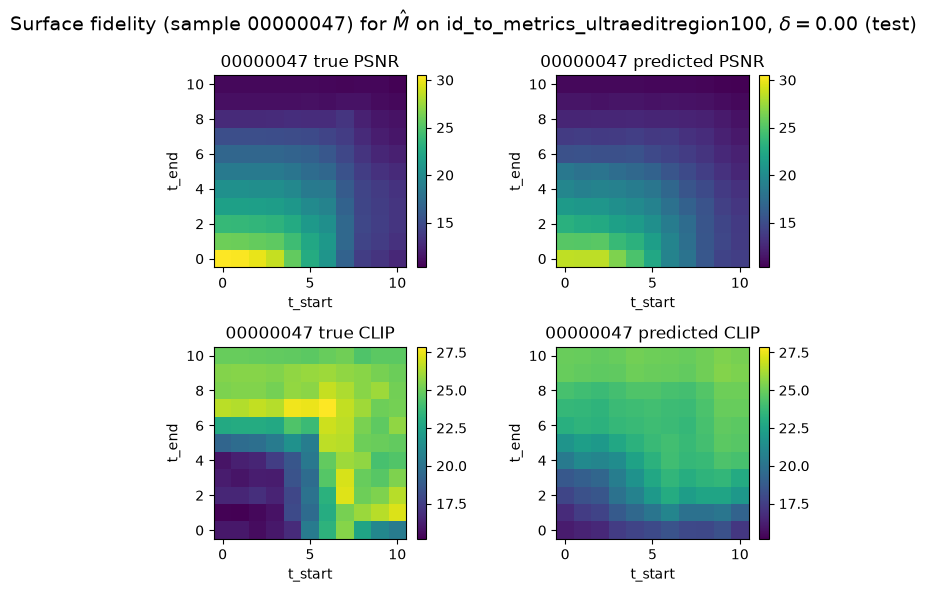

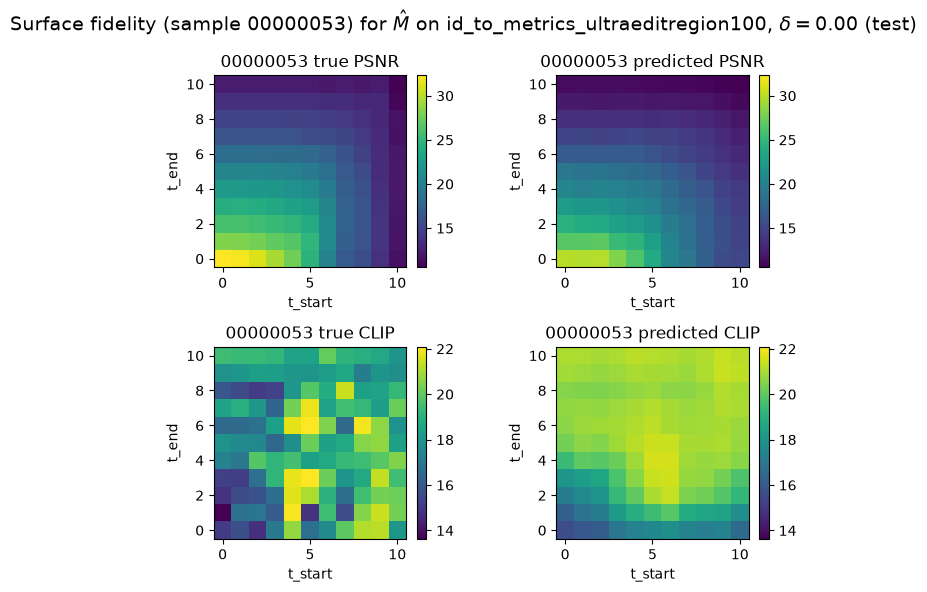

In [9]:

"""
Surface-shape fidelity — true vs predicted PSNR/CLIP heatmaps (random samples).

Each figure shows one image's 11x11 grid. True and predicted panels for the same
metric share a per-sample color scale so differences are visually comparable.

Interpretation:
  - Matching peaks/valleys in true and pred -> M captures timestep topology; T can work.
  - Pred panel flat while true has structure  -> M ignores (t_start, t_end); T will fail.
  - Pred peaks in wrong cells               -> ranking errors; check regret in eval_t.
  - Overall correct shape but blurred       -> acceptable for argmax if peak location is right.
  - Systematic offset (pred brighter/dimmer) -> calibration issue; argmax may still work if shape is preserved.
"""

rng = np.random.default_rng(SEED)
pick = rng.choice(N_IMG, size=min(4, N_IMG), replace=False)
for k in pick:
    fig, axes = plt.subplots(2, 2, figsize=(7, 6))
    panels = [
        (axes[0, 0], true_psnr[k], "true PSNR"),
        (axes[0, 1], pred_psnr[k], "predicted PSNR"),
        (axes[1, 0], true_clip[k], "true CLIP"),
        (axes[1, 1], pred_clip[k], "predicted CLIP"),
    ]
    scales = {
        "PSNR": (min(true_psnr[k].min(), pred_psnr[k].min()), max(true_psnr[k].max(), pred_psnr[k].max())),
        "CLIP": (min(true_clip[k].min(), pred_clip[k].min()), max(true_clip[k].max(), pred_clip[k].max())),
    }
    for ax, g, title in panels:
        metric = "PSNR" if "PSNR" in title else "CLIP"
        vmin, vmax = scales[metric]
        im = ax.imshow(g.T, origin="lower", cmap="viridis", vmin=vmin, vmax=vmax)
        ax.set_title(f"{SAMPLE_IDS[k]} {title}")
        ax.set_xlabel("t_start"); ax.set_ylabel("t_end")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(fig_title(f"Surface fidelity (sample {SAMPLE_IDS[k]})", PLOT_SPLIT), fontsize=14)
    plt.tight_layout(); plt.show()
